# Boston Housing Price Prediction using Deep Neural Networks

This notebook implements a deep neural network to predict housing prices using the Boston Housing dataset.

## Problem Statement:
**Linear regression by using Deep Neural network:** Implement Boston housing price prediction problem by Linear regression using Deep Neural network. Use Boston House price prediction dataset.

## Dataset Description

The Boston Housing dataset contains information about various features of houses in Boston suburbs and their prices. Each record has 13 features:

| Feature | Description |
|---------|-------------|
| CRIM | Per capita crime rate by town |
| ZN | Proportion of residential land zoned for lots over 25,000 sq.ft |
| INDUS | Proportion of non-retail business acres per town |
| CHAS | Charles River dummy variable (1 if tract bounds river; 0 otherwise) |
| NOX | Nitric oxides concentration (parts per 10 million) |
| RM | Average number of rooms per dwelling |
| AGE | Proportion of owner-occupied units built prior to 1940 |
| DIS | Weighted distances to five Boston employment centers |
| RAD | Index of accessibility to radial highways |
| TAX | Full-value property-tax rate per $10,000 |
| PTRATIO | Pupil-teacher ratio by town |
| B | 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town |
| LSTAT | % lower status of the population |

**Target Variable**: MEDV (Median value of owner-occupied homes in $1000s)

## Import Required Libraries

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1776743151.479252   59853 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776743151.552830   59853 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776743153.544200   59853 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Data Loading and Preprocessing

We'll load the Boston Housing dataset and preprocess it by:
1. Loading from the original source
2. Normalizing features using StandardScaler
3. Splitting into train, validation, and test sets

In [ ]:
def load_boston_housing_data():
    """Load and preprocess the Boston Housing dataset from its original source."""
    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target = raw_df.values[1::2, 2]

    # Normalize features and target
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X = scaler_X.fit_transform(data)
    y = scaler_y.fit_transform(target.reshape(-1, 1))

    return X, y, scaler_y

# Load and preprocess data
X, y, scaler_y = load_boston_housing_data()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (323, 13)
Validation set shape: (81, 13)
Test set shape: (102, 13)


In [ ]:
(X_train.shape ,type(X_train)),(X_test.shape ,type(X_test)) , (y_train.shape ,type(y_train)), (y_test.shape ,type(X_test))
X_train_df = pd.DataFrame(X_train)
y_train_df = pd.DataFrame(y_train)
X_train_df.head()
X_train_df.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12
count,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000
mean,-0.014221,0.008842,-0.007349,0.020231,0.020601,0.047936,0.009931,-0.008912,-0.054262,-0.044215,-0.068621,-0.026098,-0.021390
std,0.997556,1.011751,1.016810,1.035185,1.023191,1.043523,0.994697,1.012238,0.976377,0.976075,1.035982,1.046772,1.002581
min,-0.419463,-0.487722,-1.516987,-0.272599,-1.465882,-3.450002,-2.335437,-1.267069,-0.982843,-1.308051,-2.707379,-3.883072,-1.531127
25%,-0.411159,-0.487722,-0.872068,-0.272599,-0.917348,-0.565069,-0.768994,-0.838453,-0.637962,-0.767576,-0.765457,0.208827,-0.816942
50%,-0.389169,-0.487722,-0.375976,-0.272599,-0.144217,-0.107753,0.338718,-0.324650,-0.523001,-0.470612,0.066796,0.379323,-0.249939
75%,-0.108087,0.156071,1.015999,-0.272599,0.659147,0.492740,0.902353,0.736327,-0.178120,0.265859,0.806576,0.434035,0.524521
max,9.933931,3.804234,2.422565,3.668398,2.732346,3.555044,1.117494,3.287300,1.661245,1.798194,1.638828,0.441052,3.548771


## Model Architecture

We'll create a deep neural network with the following features:
- Batch normalization for training stability
- Dropout layers for regularization
- L2 regularization on dense layers
- Multiple hidden layers with decreasing units

In [ ]:
def create_model():
    """Creates an improved neural network model for housing price prediction."""
    model = tf.keras.Sequential([
        # Input layer
        tf.keras.layers.Input(shape=(13,)),
        tf.keras.layers.BatchNormalization(),

        # First hidden layer
        tf.keras.layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(0.3),

        # Second hidden layer
        tf.keras.layers.Dense(64, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(0.2),

        # Third hidden layer
        tf.keras.layers.Dense(32, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(0.1),

        # Output layer
        tf.keras.layers.Dense(1)
    ])

    return model

# Create and compile model
model = create_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mse']
)

model.summary()

E0000 00:00:1776743158.487964   59853 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 13)             │            52 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,109 (51.21 KB)

 Trainable params: 12,635 (49.36 KB)

 Non-trainable params: 474 (1.85 KB)

## Model Training

We'll train the model with:
- Early stopping to prevent overfitting
- Learning rate reduction on plateau
- Batch size of 32
- Maximum 200 epochs

In [ ]:
# Create TensorFlow datasets
batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train)).batch(batch_size)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=10,
        min_lr=0.00001,
        verbose=1
    )
]


# Train the model
history = model.fit(
    train_dataset,
    epochs=200,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 3.0914 - mse: 1.5606 - val_loss: 2.2074 - val_mse: 0.6822 - learning_rate: 0.0010
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3501 - mse: 0.8288 - val_loss: 2.0913 - val_mse: 0.5759 - learning_rate: 0.0010
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2340 - mse: 0.7229 - val_loss: 1.9992 - val_mse: 0.4944 - learning_rate: 0.0010
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1444 - mse: 0.6442 - val_loss: 1.9368 - val_mse: 0.4434 - learning_rate: 0.0010
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1516 - mse: 0.6632 - val_loss: 1.8969 - val_mse: 0.4157 - learning_rate: 0.0010
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9998 - mse: 0.5231 - val_loss: 1.8703 - val_mse: 0.4000 - learning_rate: 0.0010
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0134 - mse: 0.5476 - val_loss: 1.8547 - val_mse: 0.3952 - learning_rate: 0.0010
Epoch 8/200

## Training History Visualization

Let's visualize how the model performed during training:

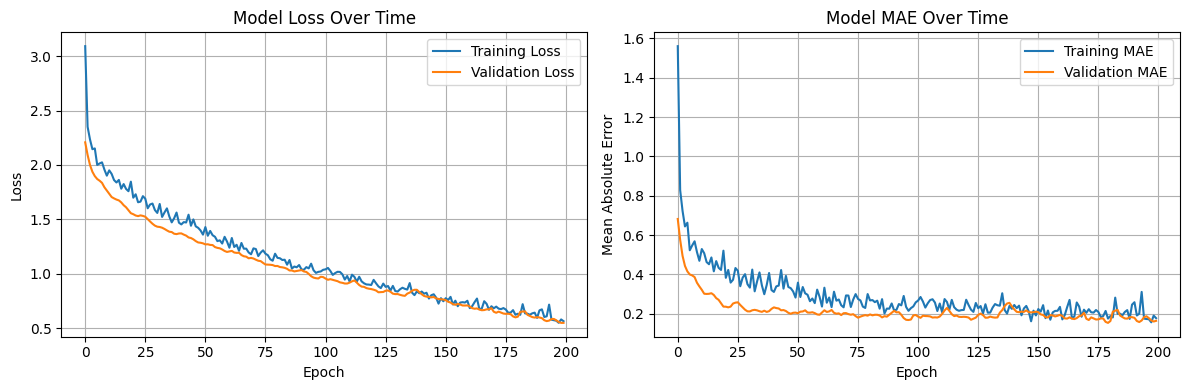

In [ ]:
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


# MAE plot
plt.subplot(1, 2, 2)
plt.plot(history.history['mse'], label='Training MAE')
plt.plot(history.history['val_mse'], label='Validation MAE')
plt.title('Model MAE Over Time')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Mean Sqaured Error')

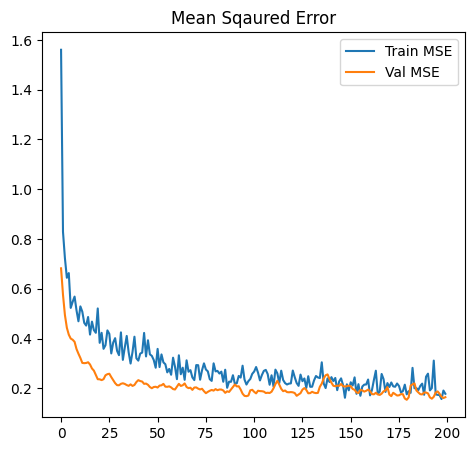

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['mse'], label='Train MSE')
plt.plot(history.history['val_mse'], label='Val MSE')
plt.legend()
plt.title('Mean Sqaured Error')

## Model Evaluation and Predictions

Let's evaluate the model on the test set and make some sample predictions:

In [ ]:
# Evaluate on test set
test_results = model.evaluate(test_dataset, verbose=0)
print(f"Test Mean Absolute Error (normalized): {test_results[1]:.4f}")

# Make predictions
test_predictions = model.predict(X_test)

# Convert predictions back to original scale
test_predictions_original = scaler_y.inverse_transform(test_predictions)
test_actual_original = scaler_y.inverse_transform(y_test)

# Calculate metrics in original scale
mae_original = np.mean(np.abs(test_predictions_original - test_actual_original))
mse = np.mean((test_predictions_original - test_actual_original) ** 2)
rmse = np.sqrt(mse)
r2 = 1 - (np.sum((test_actual_original - test_predictions_original) ** 2) /
          np.sum((test_actual_original - np.mean(test_actual_original)) ** 2))

print(f"\nTest Mean Absolute Error: ${mae_original:.2f}k")
print(f"Root Mean Square Error: ${rmse:.2f}k")
print(f"R-squared Score: {r2:.4f}")

# Show sample predictions
print("\nSample Predictions vs Actual Values (in $1000s):")
for pred, actual in zip(test_predictions_original[:5], test_actual_original[:5]):
    print(f"Predicted: ${pred[0]:.2f}k, Actual: ${actual[0]:.2f}k")

Test Mean Absolute Error (normalized): 0.1519
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Test Mean Absolute Error: $2.32k
Root Mean Square Error: $3.58k
R-squared Score: 0.8251

Sample Predictions vs Actual Values (in $1000s):
Predicted: $25.00k, Actual: $23.60k
Predicted: $32.18k, Actual: $32.40k
Predicted: $16.15k, Actual: $13.60k
Predicted: $22.97k, Actual: $22.80k
Predicted: $16.27k, Actual: $16.10k


## Prediction vs Actual Plot

Let's visualize how well our predictions match the actual values:

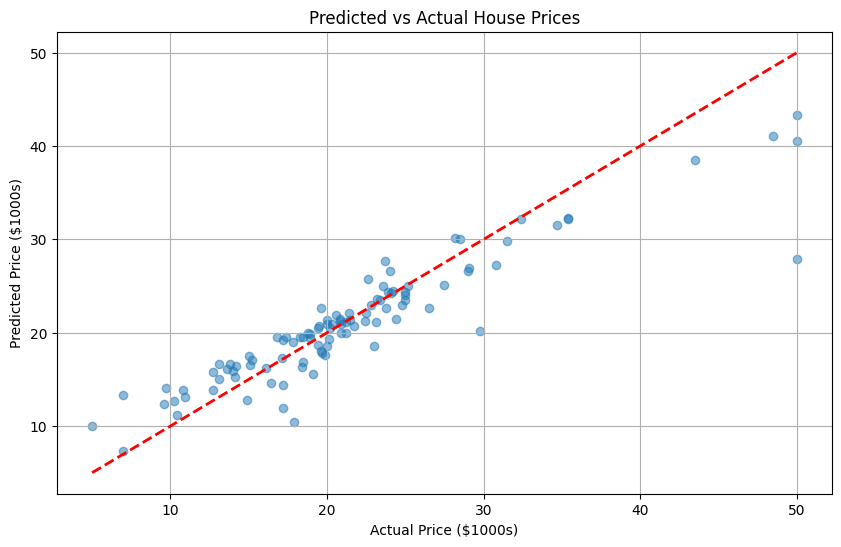

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(test_actual_original, test_predictions_original, alpha=0.5)
plt.plot([test_actual_original.min(), test_actual_original.max()],
         [test_actual_original.min(), test_actual_original.max()],
         'r--', lw=2)
plt.xlabel('Actual Price ($1000s)')
plt.ylabel('Predicted Price ($1000s)')
plt.title('Predicted vs Actual House Prices')
plt.grid(True)
plt.show()